# Hit classifier + arrival-time flow testing

Validation for the two models that, together with the light-yield flow, make up the
hurdle description of a PMT response:

| model | quantity |
|---|---|
| `HitClassifier` | `pi(c) = P(PMT sees any light \| theta, x)` |
| `FlowMatchATime` | `p(t_res \| theta, x)` for photons that did arrive |

**Part A** tests the classifier, **Part B** the arrival-time flow, **Part C** puts them
together and simulates a whole event.

A note that governs Part A throughout: at ~0.011% occupancy, **accuracy is a useless
metric** — always predicting "never hit" scores 99.99%. Judge the classifier by
calibration and AUC instead.

## Setup

In [6]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import torch
import numpy as np
import matplotlib.pyplot as plt
import importlib
import pickle
import pandas as pd
import nugget
from scipy import stats

importlib.reload(nugget.surrogates.HitClassifier)
importlib.reload(nugget.surrogates.FlowMatchATime)
importlib.reload(nugget.surrogates.FlowMatchLY)
from nugget.surrogates.HitClassifier import HitClassifier, HitLabelDataset
from nugget.surrogates.FlowMatchATime import FlowMatchATime, ArrivalTimeFlowDataset
from nugget.surrogates.FlowMatchLY import FlowMatchLY

In [7]:
device = 'cuda:3' if torch.cuda.is_available() else 'cpu'
GEOM = '../other/800_40_40_geom.csv'

HIT_CKPT    = './flow_models/best_mc_hit_model_v1.pt'
HIT_TEST    = './flow_models/mc_hit_v1_test_samples.parquet'
HIT_HIST    = './flow_models/mc_hit_v1_training_history.pkl'

ATIME_CKPT  = './flow_models/best_mc_atime_muon_flow_model_v1.pt'
ATIME_TEST  = './flow_models/mc_atime_muon_flow_v1_test_samples.parquet'
ATIME_HIST  = './flow_models/mc_atime_muon_flow_v1_training_history.pkl'

LY_CKPT     = './flow_models/best_mc_ly_muon_flow_model_v1.pt'   # for Part C

N_STEPS = 64      # ODE steps for the arrival-time flow
N_EVAL  = 100_000 # samples for the classifier tests
N_EVAL_T = 20_000 # photons for the flow tests

hit = HitClassifier(device=device, domain_size=8000)
hit.load_model(HIT_CKPT)
hit.net.eval()
print(f'hit classifier : context_dim={hit.context_dim}, '
      f'log_prior_odds={hit.log_prior_odds:.4f}')

flow = FlowMatchATime(device=device, domain_size=8000)
flow.load_model(ATIME_CKPT)
flow.net.eval()
print(f'arrival-time flow: context_dim={flow.context_dim}, n={flow.refractive_index}, '
      f'transform={flow.time_transform}(t/{flow.time_scale:g})')
print(f'  target transform mu={flow.target_mu:.4f} sigma={flow.target_sigma:.4f}')

# light-yield flow: only needed for the joint simulation in Part C
ly = FlowMatchLY(device=device, domain_size=8000)
ly.load_model(LY_CKPT)
ly.net.eval()
print(f'light-yield flow : context_dim={ly.context_dim}')

assert hit.context_dim == flow.context_dim == ly.context_dim, (
    'all three models must share the same context layout for Part C')

HitClassifier: context_dim=15, width=256, depth=6, params=797,441
hit classifier : context_dim=15, log_prior_odds=-9.1072
FlowMatchLY: context_dim=15, width=256, depth=6, params=1,849,857
arrival-time flow: context_dim=15, n=1.33, transform=asinh(t/10)
  target transform mu=1.1657 sigma=1.4324
FlowMatchLY: context_dim=15, width=256, depth=6, params=1,849,857
light-yield flow : context_dim=15


---
# Part A — hit classifier

In [3]:
ds_hit = HitLabelDataset(
    hit, parquet_path=HIT_TEST, geometry_csv_path=GEOM,
    num_samples_per_epoch=N_EVAL, seed=0, pos_frac=0.5,
    uniform_energy_zenith=False,      # natural event distribution for testing
    filter_vertex_in_domain=True,
)
ctx_h, y_h = ds_hit.get_batch(range(N_EVAL))
ctx_h = ctx_h.to(device)
y_np = y_h.numpy()
print(f'{N_EVAL:,} balanced samples, positive fraction {y_np.mean():.3f}')

HitLabelDataset: dropped 57,058 row(s) with muon vertex outside [4000.0, 4000.0, 4000.0]
HitLabelDataset: 1,094,402 hits, 11,012 events, 903,968 PMTs
  9,954,495,616 (event, PMT) cells -> occupancy P(hit) = 0.00010994 (0.0110%)
  training at pos_frac=0.5; calibrated logits need a shift of log_prior_odds = -9.1155
100,000 balanced samples, positive fraction 0.500


### A1 — training history

In [4]:
hist = pickle.load(open(HIT_HIST, 'rb'))
plt.figure(figsize=(7, 4))
plt.plot(hist['train_loss'], label='train')
if hist.get('val_loss'):
    plt.plot(hist['val_loss'], label='val')
plt.xlabel('epoch'); plt.ylabel('BCE loss'); plt.yscale('log')
plt.legend(); plt.grid(alpha=.3); plt.title('HitClassifier training'); plt.show()
print('best val:', min(hist['val_loss']) if hist.get('val_loss') else 'n/a')

FileNotFoundError: [Errno 2] No such file or directory: './flow_models/mc_hit_v1_training_history.pkl'

### A2 — calibration on the balanced sample

`calibrated=False` here, because this sample is 50/50 by construction and the
calibrated output would (correctly) report the far smaller natural occupancy.
Points should sit on the diagonal.

   mean pred   empirical         n
      0.0000      0.0000      6667
      0.0000      0.0000      6667
      0.0000      0.0000      6666
      0.0000      0.0000      6667
      0.0000      0.0000      6666
      0.0000      0.0000      6667
      0.0000      0.0000      6667
      0.5105      0.5186      6666
      0.9866      0.9904      6667
      0.9955      0.9964      6666
      0.9977      0.9985      6667
      0.9986      0.9984      6667
      0.9992      0.9988      6666
      0.9995      0.9993      6667
      0.9997      0.9997      6667

expected calibration error (ECE) = 0.00097


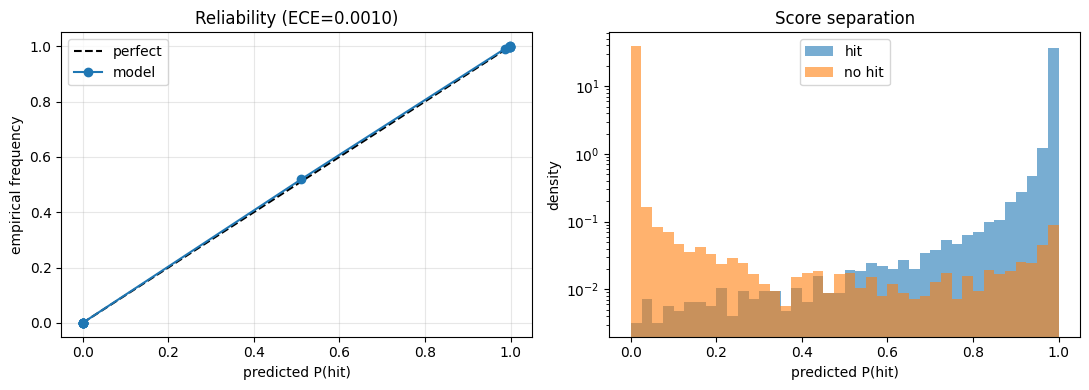

In [5]:
rows = hit.reliability(ctx_h, y_h, n_bins=15, calibrated=False)
pred = np.array([r[0] for r in rows]); emp = np.array([r[1] for r in rows])
cnt  = np.array([r[2] for r in rows])

print(f'  {"mean pred":>10}  {"empirical":>10}  {"n":>8}')
for p, e, n in rows:
    print(f'  {p:10.4f}  {e:10.4f}  {n:8d}')

p_unc = hit.predict_hit_prob(ctx_h, calibrated=False).detach().cpu().numpy()
ece = np.sum(cnt / cnt.sum() * np.abs(pred - emp))
print(f'\nexpected calibration error (ECE) = {ece:.5f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([0, 1], [0, 1], 'k--', label='perfect')
ax[0].plot(pred, emp, 'o-', label='model')
ax[0].set_xlabel('predicted P(hit)'); ax[0].set_ylabel('empirical frequency')
ax[0].set_title(f'Reliability (ECE={ece:.4f})'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].hist(p_unc[y_np == 1], bins=40, alpha=.6, label='hit', density=True)
ax[1].hist(p_unc[y_np == 0], bins=40, alpha=.6, label='no hit', density=True)
ax[1].set_xlabel('predicted P(hit)'); ax[1].set_ylabel('density')
ax[1].set_yscale('log'); ax[1].set_title('Score separation'); ax[1].legend()
plt.tight_layout(); plt.show()

### A3 — ROC and precision–recall

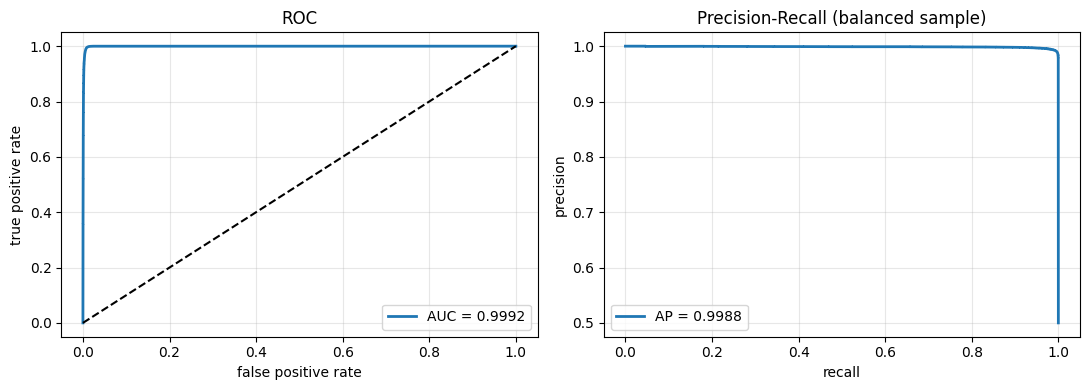

ROC AUC = 0.9992   AP = 0.9988
NB: PR is computed on the BALANCED sample; on natural data the baseline precision would be the occupancy, 1.10e-04.


In [6]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fpr, tpr, _ = roc_curve(y_np, p_unc)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(y_np, p_unc)
ap = average_precision_score(y_np, p_unc)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlabel('false positive rate'); ax[0].set_ylabel('true positive rate')
ax[0].set_title('ROC'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(rec, prec, lw=2, label=f'AP = {ap:.4f}')
ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision')
ax[1].set_title('Precision-Recall (balanced sample)'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f'ROC AUC = {roc_auc:.4f}   AP = {ap:.4f}')
print('NB: PR is computed on the BALANCED sample; on natural data the baseline '
      f'precision would be the occupancy, {ds_hit.p_hit:.2e}.')

### A4 — does the prior correction recover the true occupancy?

The decisive test of `log_prior_odds`. Draw `(event, PMT)` pairs uniformly — i.e. from
the *natural* distribution, not the balanced one — and average the calibrated
probability. It should reproduce the measured occupancy.

In [7]:
rng = np.random.default_rng(0)
M = 400_000
ev = ds_hit._sample_events(M)
gi = rng.integers(0, ds_hit._n_geo, size=M)
ctx_nat = hit.build_context(
    torch.from_numpy(ds_hit._geo_pos[gi]),
    torch.from_numpy(ds_hit._ev_vertex[ev]),
    torch.from_numpy(ds_hit._ev_energy[ev]),
    torch.from_numpy(ds_hit._ev_zenith[ev]),
    torch.from_numpy(ds_hit._ev_azimuth[ev]),
    torch.from_numpy(ds_hit._geo_dir[gi]),
).to(device)
p_nat = hit.predict_hit_prob(ctx_nat, calibrated=True).detach().cpu().numpy()
truth_nat = ds_hit._is_hit(ev, gi).mean()

print(f'calibrated  mean P(hit) over natural sample = {p_nat.mean():.6g}')
print(f'empirical   hit rate in the same sample     = {truth_nat:.6g}')
print(f'dataset-wide occupancy                      = {ds_hit.p_hit:.6g}')
print(f'\nratio model/dataset = {p_nat.mean()/ds_hit.p_hit:.3f}   (1.0 = calibrated)')
print(f'log_prior_odds applied = {hit.log_prior_odds:.4f}')

calibrated  mean P(hit) over natural sample = 8.60702e-05
empirical   hit rate in the same sample     = 0.0001575
dataset-wide occupancy                      = 0.00010994

ratio model/dataset = 0.783   (1.0 = calibrated)
log_prior_odds applied = -9.1072


### A5 — does P(hit) follow the physics?

Calibrated hit probability against perpendicular distance to the track and against
energy, compared with the empirical hit rate in the same bins.

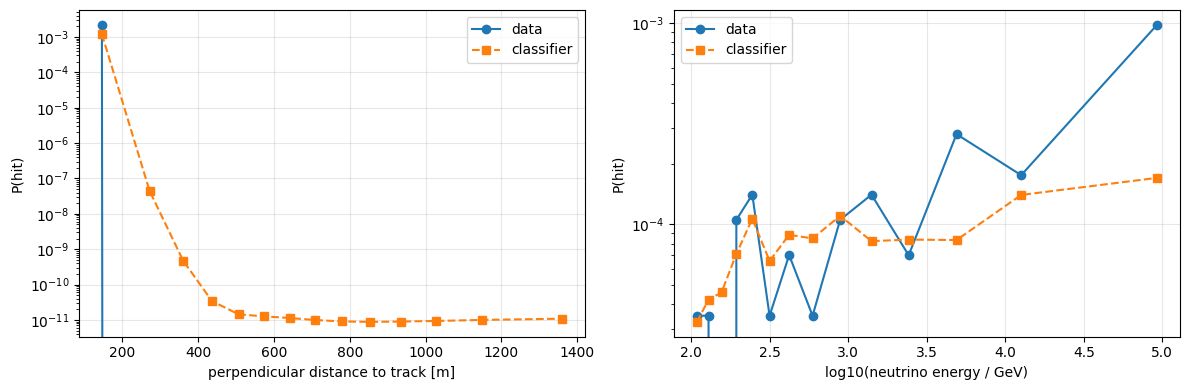

In [9]:
u = np.stack([np.sin(ds_hit._ev_zenith[ev]) * np.cos(ds_hit._ev_azimuth[ev]),
              np.sin(ds_hit._ev_zenith[ev]) * np.sin(ds_hit._ev_azimuth[ev]),
              np.cos(ds_hit._ev_zenith[ev])], 1)
rel = ds_hit._geo_pos[gi] - ds_hit._ev_vertex[ev]
along = (rel * u).sum(1)
perp = np.linalg.norm(rel - along[:, None] * u, axis=1)
logE = np.log10(ds_hit._ev_energy[ev])
truth = ds_hit._is_hit(ev, gi).astype(float)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, x, lab in [(ax[0], perp, 'perpendicular distance to track [m]'),
                  (ax[1], logE, 'log10(neutrino energy / GeV)')]:
    qs = np.quantile(x, np.linspace(0, 1, 15))
    idx = np.digitize(x, qs[1:-1])
    cx, dy, my = [], [], []
    for b in range(14):
        m = idx == b
        if m.sum() < 200:
            continue
        cx.append(x[m].mean()); dy.append(truth[m].mean()); my.append(p_nat[m].mean())
    a.plot(cx, dy, 'o-', label='data')
    a.plot(cx, my, 's--', label='classifier')
    a.set_xlabel(lab); a.set_ylabel('P(hit)'); a.set_yscale('log')
    a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
# Part B — arrival-time flow

The modelled quantity is the Cherenkov time residual

`t_res = t_hit - t_geom(theta, x)`

`t_geom` is the earliest direct-photon arrival time, so `t_res` isolates scattering
plus PMT jitter. Negative values are physical (jitter) and the transform is designed
to keep them.

In [8]:
ds_t = ArrivalTimeFlowDataset(
    flow, parquet_path=ATIME_TEST, geometry_csv_path=GEOM, uniform_energy_zenith=False, filter_vertex_in_domain=True, seed =0
)
ctx_t, t_true = ds_t.get_batch(range(N_EVAL_T))
ctx_t = ctx_t.to(device)
t_np = t_true.numpy().astype(np.float64)
print(f'{N_EVAL_T:,} photons | t_res: p1={np.percentile(t_np,1):.2f} '
      f'median={np.median(t_np):.2f} p99={np.percentile(t_np,99):.2f} '
      f'frac<0={np.mean(t_np<0):.4f}')

ArrivalTimeFlowDataset: 'times' layout = ragged list per row; 8,695,983 photons over 1,198,066 rows
ArrivalTimeFlowDataset: dropped 58,567 row(s) with muon vertex outside [4000.0, 4000.0, 4000.0]
ArrivalTimeFlowDataset: 1,139,499 rows (PMTs), 8,317,166 photons, 11,017 events, 8,317,166 samples/epoch
  photons/row: mean 7.30, median 1, max 161789
20,000 photons | t_res: p1=-28.96 median=4.48 p99=229.75 frac<0=0.1013


### B1 — training history

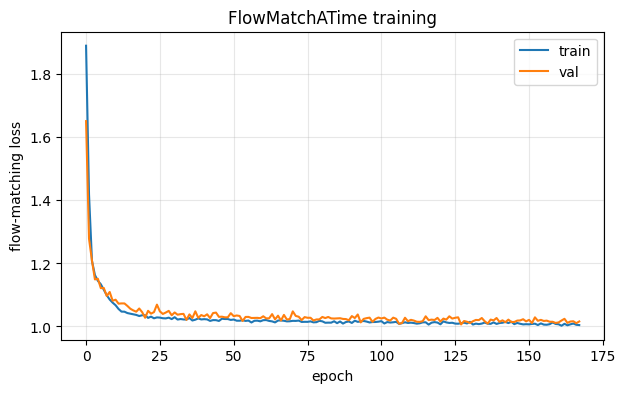

best val: 1.006454668703019
(the FM loss has a non-zero floor - only relative changes are meaningful)


In [9]:
hist_t = pickle.load(open(ATIME_HIST, 'rb'))
plt.figure(figsize=(7, 4))
plt.plot(hist_t['train_loss'], label='train')
if hist_t.get('val_loss'):
    plt.plot(hist_t['val_loss'], label='val')
plt.xlabel('epoch'); plt.ylabel('flow-matching loss'); plt.legend(); plt.grid(alpha=.3)
plt.title('FlowMatchATime training'); plt.show()
print('best val:', min(hist_t['val_loss']) if hist_t.get('val_loss') else 'n/a')
print('(the FM loss has a non-zero floor - only relative changes are meaningful)')

### B2 — density normalisation

`integral p(z|c) dz` must be 1. A sign error in the divergence accumulation still
produces plausible samples while corrupting every likelihood, so check this first.

In [10]:
zs = torch.linspace(-8, 8, 1601, device=device,
                    dtype=flow.param_dtype).reshape(-1, 1)
print('integral of p(z|c) dz  (should be 1.000)')
for k in range(5):
    cc = ctx_t[k:k+1].repeat(len(zs), 1)
    lp = flow.log_prob_z(zs, cc, n_steps=N_STEPS)
    print(f'  context {k}: {torch.trapezoid(lp.exp().double(), zs.reshape(-1).double()).item():.5f}')

integral of p(z|c) dz  (should be 1.000)
  context 0: 1.01062
  context 1: 1.03000
  context 2: 1.02118
  context 3: 1.01992
  context 4: 1.03428


### B3 — ODE step convergence

Unlike the light-yield model there is **no dequantisation** here (arrival times are
already continuous), so `log_prob_time_residual` is deterministic and this test
measures genuine ODE discretisation error. It should fall monotonically.

In [11]:
sub = ctx_t[:2000]
t_sub = t_true[:2000].to(device)
ref = flow.log_prob_time_residual(t_sub, sub, n_steps=256).double()
print('n_steps   mean|log p - log p(256 steps)|')
for n in [4, 8, 16, 32, 64, 128]:
    lp = flow.log_prob_time_residual(t_sub, sub, n_steps=n).double()
    print(f'  {n:4d}     {(lp - ref).abs().mean().item():.6f}')

n_steps   mean|log p - log p(256 steps)|
     4     0.421997
     8     0.306087
    16     0.140829
    32     0.055331
    64     0.029729
   128     0.009316


### B4 — marginal consistency of the time residual

data  p1=   -28.96 p25=    1.31 median=    4.48 p75=   12.38 p99=   229.75 frac<0=0.1013 max=828
flow  p1=   -22.41 p25=    2.53 median=    8.04 p75=   23.83 p99=   295.88 frac<0=0.0941 max=1468


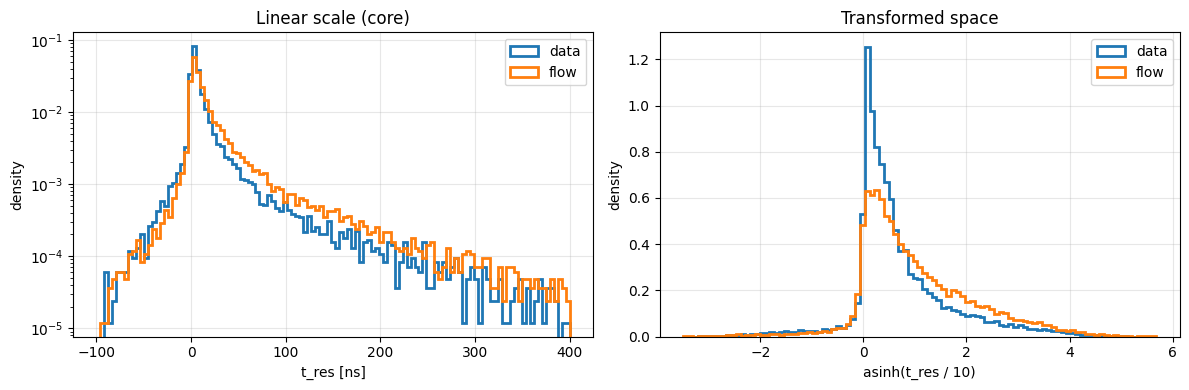

KS(data, flow) on t_res: 0.1599


In [13]:
t_samp = flow.sample_time_residual(ctx_t, n_steps=N_STEPS).cpu().numpy().astype(np.float64)

def summarise(name, a):
    print(f'{name:5s} p1={np.percentile(a,1):9.2f} p25={np.percentile(a,25):8.2f} '
          f'median={np.median(a):8.2f} p75={np.percentile(a,75):8.2f} '
          f'p99={np.percentile(a,99):9.2f} frac<0={np.mean(a<0):.4f} max={a.max():.0f}')
summarise('data', t_np); summarise('flow', t_samp)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
b = np.linspace(-100, 400, 120)
ax[0].hist(t_np, bins=b, histtype='step', lw=2, density=True, label='data')
ax[0].hist(t_samp, bins=b, histtype='step', lw=2, density=True, label='flow')
ax[0].set_xlabel('t_res [ns]'); ax[0].set_ylabel('density'); ax[0].set_yscale('log')
ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_title('Linear scale (core)')

# in transformed space, where the flow actually works
w_d = flow.transform_time(torch.from_numpy(t_np)).numpy()
w_f = flow.transform_time(torch.from_numpy(t_samp)).numpy()
b2 = np.linspace(min(w_d.min(), w_f.min()), max(w_d.max(), w_f.max()), 100)
ax[1].hist(w_d, bins=b2, histtype='step', lw=2, density=True, label='data')
ax[1].hist(w_f, bins=b2, histtype='step', lw=2, density=True, label='flow')
ax[1].set_xlabel(f'{flow.time_transform}(t_res / {flow.time_scale:g})')
ax[1].set_ylabel('density'); ax[1].legend(); ax[1].grid(alpha=.3)
ax[1].set_title('Transformed space')
plt.tight_layout(); plt.show()
print('KS(data, flow) on t_res:', stats.ks_2samp(t_np, t_samp).statistic.round(4))

### B5 — calibration (PIT)

`t_res` is continuous, so the ordinary PIT applies directly: `F(t_res | c)` should be
`Uniform(0,1)`. `cdf_time_residual` is exact — the 1-D flow map and the transform are
both monotone, so the CDF is the base-space Gaussian CDF of the transported point.

- **U-shaped** -> too narrow  - **∩-shaped** -> too wide  - **sloped** -> biased

PIT mean = 0.4062 (want 0.5), std = 0.2526 (want 0.2887)
KS vs Uniform(0,1): stat = 0.1702, p = 0


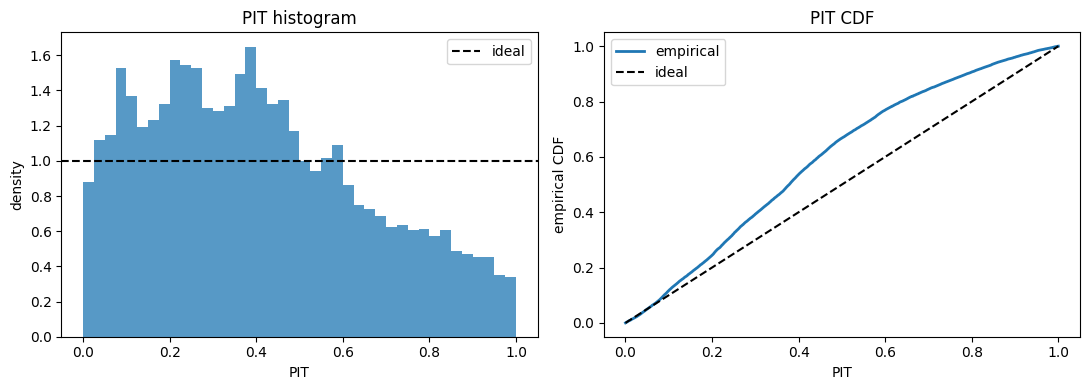


calibration split by t_res regime:
       t_res range       n  PIT mean       KS          p
[-1000000000,       0)    2025    0.1440   0.6085   0.00e+00
[       0,      10)   12145    0.3595   0.2802   0.00e+00
[      10,      50)    4327    0.5503   0.1213   5.64e-56
[      50,     200)    1238    0.6998   0.3357  7.00e-125
[     200,1000000000)     265    0.8225   0.5772   3.08e-84


In [14]:
pit = flow.cdf_time_residual(t_true.to(device), ctx_t, n_steps=N_STEPS).cpu().numpy()
ks = stats.kstest(pit, 'uniform')
print(f'PIT mean = {pit.mean():.4f} (want 0.5), std = {pit.std():.4f} '
      f'(want {1/np.sqrt(12):.4f})')
print(f'KS vs Uniform(0,1): stat = {ks.statistic:.4f}, p = {ks.pvalue:.3g}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(pit, bins=40, density=True, alpha=.75)
ax[0].axhline(1.0, color='k', ls='--', label='ideal')
ax[0].set_xlabel('PIT'); ax[0].set_ylabel('density'); ax[0].set_title('PIT histogram')
ax[0].legend()
ax[1].plot(np.sort(pit), np.linspace(0, 1, len(pit)), lw=2, label='empirical')
ax[1].plot([0, 1], [0, 1], 'k--', label='ideal')
ax[1].set_xlabel('PIT'); ax[1].set_ylabel('empirical CDF'); ax[1].legend()
ax[1].set_title('PIT CDF')
plt.tight_layout(); plt.show()

print('\ncalibration split by t_res regime:')
print(f'{"t_res range":>18} {"n":>7} {"PIT mean":>9} {"KS":>8} {"p":>10}')
for lo, hi in [(-1e9, 0), (0, 10), (10, 50), (50, 200), (200, 1e9)]:
    m = (t_np >= lo) & (t_np < hi)
    if m.sum() < 50:
        continue
    k = stats.kstest(pit[m], 'uniform')
    print(f'[{lo:>8.0f},{hi:>8.0f}) {m.sum():>7d} {pit[m].mean():>9.4f} '
          f'{k.statistic:>8.4f} {k.pvalue:>10.2e}')

### B6 — one PMT's conditional arrival-time density

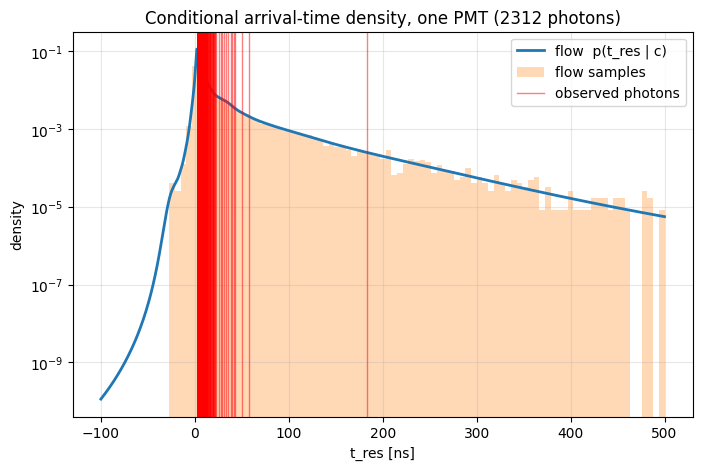

integral of the plotted density = 1.0147 (<1 if the grid truncates the tail)


In [21]:
test_row_photons = 0
photon_thres = 500
while test_row_photons < photon_thres:
    i = np.random.randint(0, len(ds_t._photons_per_row))
    test_row_photons = ds_t._photons_per_row[i]
# i = int(np.argmax(ds_t._photons_per_row > 20)) if (ds_t._photons_per_row > 20).any() else 0
# rows_i = np.array([i])
start = ds_t._row_photon_start[i]
n_ph = ds_t._photons_per_row[i]
t_obs = ds_t._t_hit[start:start + n_ph]

c1 = flow.build_context(
    torch.from_numpy(ds_t._point[rows_i]), torch.from_numpy(ds_t._muon_pos[rows_i]),
    torch.from_numpy(ds_t._energy[rows_i]), torch.from_numpy(ds_t._zenith[rows_i]),
    torch.from_numpy(ds_t._azimuth[rows_i]),
    torch.from_numpy(ds_t._pmt_direction[rows_i])).to(device)
res_obs = flow.time_residual(
    torch.from_numpy(t_obs), torch.from_numpy(np.tile(ds_t._point[i], (n_ph, 1))),
    torch.from_numpy(np.tile(ds_t._muon_pos[i], (n_ph, 1))),
    zeniths=torch.from_numpy(np.full(n_ph, ds_t._zenith[i])),
    azimuths=torch.from_numpy(np.full(n_ph, ds_t._azimuth[i]))).numpy()

grid = torch.linspace(-100, 500, 800, device=device, dtype=flow.param_dtype)
lp = flow.log_prob_time_residual(grid, c1.repeat(len(grid), 1), n_steps=N_STEPS)
dens = lp.exp().cpu().numpy()
samp = flow.sample_time_residual(c1.repeat(20000, 1), n_steps=N_STEPS).cpu().numpy()

plt.figure(figsize=(8, 5))
plt.plot(grid.cpu().numpy(), dens, lw=2, label='flow  p(t_res | c)')
plt.hist(samp, bins=np.linspace(-100, 500, 100), density=True, alpha=.3,
         label='flow samples')
for k, r in enumerate(res_obs):
    plt.axvline(r, color='red', alpha=.5, lw=1,
                label='observed photons' if k == 0 else None)
plt.xlabel('t_res [ns]'); plt.ylabel('density'); plt.yscale('log')
plt.legend(); plt.grid(alpha=.3)
plt.title(f'Conditional arrival-time density, one PMT ({n_ph} photons)')
plt.show()
print('integral of the plotted density =',
      round(float(np.trapezoid(dens, grid.cpu().numpy())), 4),
      '(<1 if the grid truncates the tail)')

### B7 — conditional trends

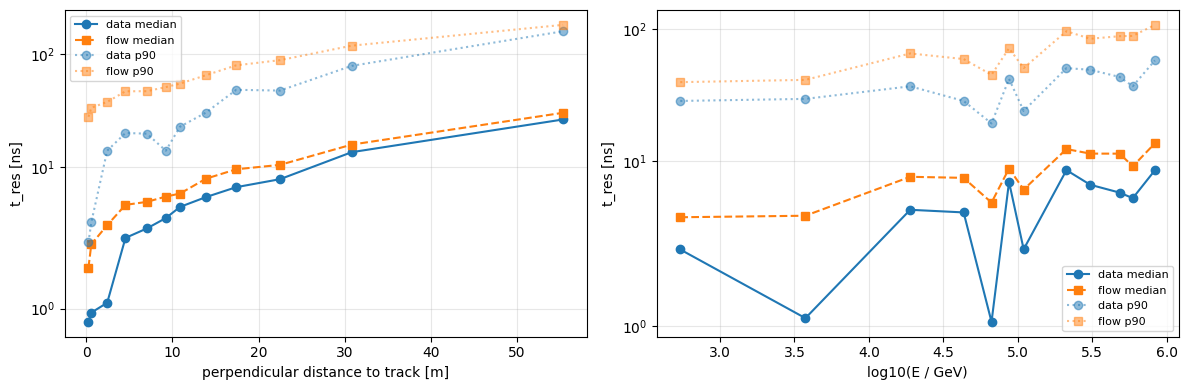

In [22]:
ph, rws = ds_t._sample_photons(N_EVAL_T)
pts, vert = ds_t._point[rws], ds_t._muon_pos[rws]
zz, aa = ds_t._zenith[rws], ds_t._azimuth[rws]
uu = -np.stack([np.sin(zz)*np.cos(aa), np.sin(zz)*np.sin(aa), np.cos(zz)], 1)
relv = pts - vert
al = (relv*uu).sum(1)
pp = np.linalg.norm(relv - al[:, None]*uu, axis=1)

ctx_s = flow.build_context(
    torch.from_numpy(pts), torch.from_numpy(vert),
    torch.from_numpy(ds_t._energy[rws]), torch.from_numpy(zz),
    torch.from_numpy(aa), torch.from_numpy(ds_t._pmt_direction[rws])).to(device)
t_d = flow.time_residual(torch.from_numpy(ds_t._t_hit[ph]), torch.from_numpy(pts),
                         torch.from_numpy(vert), zeniths=torch.from_numpy(zz),
                         azimuths=torch.from_numpy(aa)).numpy()
t_m = flow.sample_time_residual(ctx_s, n_steps=N_STEPS).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, x, lab in [(ax[0], pp, 'perpendicular distance to track [m]'),
                  (ax[1], np.log10(ds_t._energy[rws]), 'log10(E / GeV)')]:
    qs = np.quantile(x, np.linspace(0, 1, 13))
    idx = np.digitize(x, qs[1:-1])
    cx, dmed, mmed, dhi, mhi = [], [], [], [], []
    for b in range(12):
        m = idx == b
        if m.sum() < 50:
            continue
        cx.append(x[m].mean())
        dmed.append(np.median(t_d[m])); mmed.append(np.median(t_m[m]))
        dhi.append(np.percentile(t_d[m], 90)); mhi.append(np.percentile(t_m[m], 90))
    a.plot(cx, dmed, 'o-', color='C0', label='data median')
    a.plot(cx, mmed, 's--', color='C1', label='flow median')
    a.plot(cx, dhi, 'o:', color='C0', alpha=.5, label='data p90')
    a.plot(cx, mhi, 's:', color='C1', alpha=.5, label='flow p90')
    a.set_xlabel(lab); a.set_ylabel('t_res [ns]'); a.set_yscale('symlog')
    a.legend(fontsize=8); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
# Part C — all three models together

Simulate a whole event end to end:

1. **`HitClassifier`** over the *entire geometry* -> which PMTs fire,
2. **`FlowMatchLY`** at each fired PMT -> how many photons `q`,
3. **`FlowMatchATime`** -> `q` arrival times at that PMT.

That is the complete hurdle factorisation,
`p(q, t | c) = pi(c) . p_LY(q | c, q>=1) . prod_j p_T(t_j | c)`.

Handily, the arrival-time parquet gives the *data* light yield for free: the number of
entries in a PMT's `times` list **is** its photon count, so the real and simulated
sides are directly comparable without touching a second file.

Part A checks `pi(c)` alone and Part B checks `p(t|c)` on PMTs already known to be hit;
only here do the error modes compound the way they will in real use.

In [34]:
# a real event, from the arrival-time test set
rng2 = np.random.default_rng()
for _ in range(200):
    evc = int(rng2.choice(ds_t._events))
    rows_ev = ds_t._event_rows[evc]
    if len(rows_ev) >= 200:
        break
r0 = rows_ev[0]
print(f'event {evc}: {len(rows_ev)} hit PMTs, E={ds_t._energy[r0]:.3g} GeV, '
      f'zenith={ds_t._zenith[r0]:.3f}')

# --- classifier over the whole geometry at this event's parameters ---
geo_all = pd.read_csv(GEOM, usecols=['om_x','om_y','om_z',
                                     'pmt_dir_x','pmt_dir_y','pmt_dir_z'])
G_pos = geo_all[['om_x','om_y','om_z']].to_numpy(np.float32)
G_dir = geo_all[['pmt_dir_x','pmt_dir_y','pmt_dir_z']].to_numpy(np.float32)
NG = len(G_pos)

p_all = np.empty(NG, np.float64)
B = 65536
for s in range(0, NG, B):
    e = min(s + B, NG)
    b = e - s
    c = hit.build_context(
        torch.from_numpy(G_pos[s:e]),
        torch.from_numpy(np.tile(ds_t._muon_pos[r0], (b, 1))),
        torch.from_numpy(np.full(b, ds_t._energy[r0], np.float32)),
        torch.from_numpy(np.full(b, ds_t._zenith[r0], np.float32)),
        torch.from_numpy(np.full(b, ds_t._azimuth[r0], np.float32)),
        torch.from_numpy(G_dir[s:e])).to(device)
    p_all[s:e] = hit.predict_hit_prob(c, calibrated=True).detach().cpu().numpy()

fired = rng2.random(NG) < p_all
print(f'classifier: expected {p_all.sum():.1f} hits, sampled {fired.sum()}, '
      f'data has {len(rows_ev)}')

event 2950: 579 hit PMTs, E=2.68e+04 GeV, zenith=1.261
classifier: expected 216.2 hits, sampled 224, data has 579


In [35]:
# --- step 2: light yield at each fired PMT, from the LY flow ---
idx_f = np.flatnonzero(fired)
NF = len(idx_f)


def event_ctx(model, gidx):
    n = len(gidx)
    return model.build_context(
        torch.from_numpy(G_pos[gidx]),
        torch.from_numpy(np.tile(ds_t._muon_pos[r0], (n, 1))),
        torch.from_numpy(np.full(n, ds_t._energy[r0], np.float32)),
        torch.from_numpy(np.full(n, ds_t._zenith[r0], np.float32)),
        torch.from_numpy(np.full(n, ds_t._azimuth[r0], np.float32)),
        torch.from_numpy(G_dir[gidx])).to(device)


if NF:
    q_sim = ly.sample_light_yield(event_ctx(ly, idx_f), n_steps=N_STEPS,
                                  discrete=True).detach().cpu().numpy()
else:
    q_sim = np.array([])

# data side: photon count per hit PMT is just the length of its `times` list
q_real = ds_t._photons_per_row[rows_ev].astype(np.float64)
pos_real = ds_t._point[rows_ev]

print(f'hit PMTs      : sim {NF:5d}   data {len(rows_ev):5d}')
if NF:
    print(f'total photons : sim {q_sim.sum():8.0f}   data {q_real.sum():8.0f}')
    print(f'LY per PMT    : sim median {np.median(q_sim):5.1f} max {q_sim.max():7.0f} | '
          f'data median {np.median(q_real):5.1f} max {q_real.max():7.0f}')

hit PMTs      : sim   224   data   579
total photons : sim     1168   data     3051
LY per PMT    : sim median   1.0 max     224 | data median   1.0 max     408


In [38]:
# --- step 3: arrival times, q_i photons at each fired PMT ---
# The 3-D panel shows the EARLIEST photon per PMT, so cap the draws per PMT: the
# minimum of the first PHOTON_CAP samples is a fine estimator of the first hit and
# keeps a bright PMT (LY can reach 1e4+) from dominating the cost.
PHOTON_CAP = 64

# np.inf, not np.nan: np.minimum.at propagates NaN and would blank every entry
t_first_sim = np.full(NF, np.inf)
if NF:
    n_draw = np.minimum(q_sim, PHOTON_CAP).astype(np.int64)
    n_draw = np.maximum(n_draw, 1)
    rep = np.repeat(np.arange(NF), n_draw)
    gi_rep = idx_f[rep]
    ctx_rep = event_ctx(flow, gi_rep)
    t_all = flow.sample_arrival_time(
        ctx_rep, torch.from_numpy(G_pos[gi_rep]),
        torch.from_numpy(np.tile(ds_t._muon_pos[r0], (len(rep), 1))),
        zeniths=torch.from_numpy(np.full(len(rep), ds_t._zenith[r0], np.float32)),
        azimuths=torch.from_numpy(np.full(len(rep), ds_t._azimuth[r0], np.float32)),
        n_steps=N_STEPS).detach().cpu().numpy()
    np.minimum.at(t_first_sim, rep, t_all)   # earliest photon per PMT
    print(f'sampled {len(rep):,} photons across {NF} PMTs '
          f'(cap {PHOTON_CAP}/PMT)')

# data: earliest photon per hit PMT
t_first_real = np.array([
    ds_t._t_hit[ds_t._row_photon_start[r]:
                ds_t._row_photon_start[r] + ds_t._photons_per_row[r]].min()
    for r in rows_ev])

if NF:
    print(f'first-hit time: sim   p1={np.percentile(t_first_sim,1):8.0f} '
          f'median={np.median(t_first_sim):8.0f} p99={np.percentile(t_first_sim,99):8.0f}')
    print(f'                data  p1={np.percentile(t_first_real,1):8.0f} '
          f'median={np.median(t_first_real):8.0f} p99={np.percentile(t_first_real,99):8.0f}')

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:3 and cpu!

In [39]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import Normalize

# shared colour scale (first-hit time) and size scale (light yield, log)
tmin = min(t_first_real.min(), t_first_sim.min()) if NF else t_first_real.min()
tmax = max(t_first_real.max(), t_first_sim.max()) if NF else t_first_real.max()
norm = Normalize(vmin=tmin, vmax=tmax)
size_fn = lambda q: 8.0 + 55.0 * np.log10(q + 1.0)
lims = [(G_pos[:, k].min(), G_pos[:, k].max()) for k in range(3)]

fig = plt.figure(figsize=(14, 6.5))
panels = [('Data (real event)', pos_real, t_first_real, q_real),
          ('Simulated (hit + LY + time flows)', G_pos[idx_f], t_first_sim, q_sim)]
scs = []
for i, (title, xyz, tt, qq) in enumerate(panels):
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    ax.scatter(G_pos[:, 0], G_pos[:, 1], G_pos[:, 2], s=1, c='lightgray',
               alpha=.05, linewidth=0, depthshade=False)
    if len(xyz):
        sc = ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=size_fn(qq), c=tt,
                        cmap='plasma', norm=norm, edgecolor='k', linewidth=.3,
                        depthshade=False)
        scs.append(sc)
    ax.set_xlim(*lims[0]); ax.set_ylim(*lims[1]); ax.set_zlim(*lims[2])
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
    ax.set_title(f'{title}\n{len(xyz)} PMT(s), total LY = {qq.sum():.0f}')
    ax.view_init(elev=18, azim=-60)
if scs:
    fig.colorbar(scs[0], ax=fig.get_axes(), shrink=.65, pad=.02,
                 label='first-hit time [ns]')
plt.suptitle(f'Event {evc}: real vs. fully simulated event '
             f'(size ~ light yield, colour = first-hit time)')
plt.show()

NameError: name 't_first_real' is not defined

In [ ]:
# --- aggregate comparison of the simulated vs real event ---
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

if NF:
    b = np.logspace(0, np.log10(max(q_real.max(), q_sim.max())) + .05, 30)
    ax[0].hist(q_real, bins=b, histtype='step', lw=2, density=True, label='data')
    ax[0].hist(q_sim, bins=b, histtype='step', lw=2, density=True, label='sim')
    ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_xlabel('light yield per PMT'); ax[0].set_ylabel('density')
ax[0].set_title('Light yield'); ax[0].legend(); ax[0].grid(alpha=.3)

if NF:
    b = np.linspace(min(t_first_real.min(), t_first_sim.min()),
                    max(t_first_real.max(), t_first_sim.max()), 40)
    ax[1].hist(t_first_real, bins=b, histtype='step', lw=2, density=True, label='data')
    ax[1].hist(t_first_sim, bins=b, histtype='step', lw=2, density=True, label='sim')
ax[1].set_xlabel('first-hit time [ns]'); ax[1].set_ylabel('density')
ax[1].set_title('Timing'); ax[1].legend(); ax[1].grid(alpha=.3)

# radial profile: perpendicular distance of lit PMTs from the track
uev_ = -np.array([np.sin(ds_t._zenith[r0])*np.cos(ds_t._azimuth[r0]),
                  np.sin(ds_t._zenith[r0])*np.sin(ds_t._azimuth[r0]),
                  np.cos(ds_t._zenith[r0])])
def perp_of(xyz):
    rel = xyz - ds_t._muon_pos[r0]
    al = rel @ uev_
    return np.linalg.norm(rel - al[:, None]*uev_, axis=1)
pr_real, pr_sim = perp_of(pos_real), (perp_of(G_pos[idx_f]) if NF else np.array([]))
if NF:
    b = np.linspace(0, max(pr_real.max(), pr_sim.max()), 30)
    ax[2].hist(pr_real, bins=b, histtype='step', lw=2, density=True, label='data')
    ax[2].hist(pr_sim, bins=b, histtype='step', lw=2, density=True, label='sim')
ax[2].set_xlabel('perpendicular distance to track [m]'); ax[2].set_ylabel('density')
ax[2].set_title('Spatial spread of lit PMTs'); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

if NF:
    print(f'KS(data, sim)  light yield : {stats.ks_2samp(q_real, q_sim).statistic:.4f}')
    print(f'KS(data, sim)  first time  : '
          f'{stats.ks_2samp(t_first_real, t_first_sim).statistic:.4f}')
    print(f'KS(data, sim)  perp dist   : {stats.ks_2samp(pr_real, pr_sim).statistic:.4f}')

## Summary checklist

**Part A — classifier**

| test | pass condition |
|---|---|
| A2 reliability | points on the diagonal, ECE small |
| A3 ROC / PR | AUC well above 0.5 |
| A4 prior correction | calibrated mean / true occupancy ≈ 1.0 |
| A5 trends | P(hit) falls with distance, rises with energy, tracking the data |

**Part B — arrival-time flow**

| test | pass condition |
|---|---|
| B2 normalisation | integrals within ~1% of 1.0 |
| B3 ODE steps | error falls monotonically, flat past the chosen `N_STEPS` |
| B4 marginal | distributions overlap in both linear and transformed space |
| B5 PIT | flat histogram, diagonal CDF, no regime badly skewed |
| B7 trends | median and p90 residual both track the data vs distance |

**Part C — all three jointly**

| check | pass condition |
|---|---|
| hit count | simulated ≈ real number of lit PMTs |
| light yield | LY-per-PMT distributions overlap, small KS |
| timing | first-hit time distributions overlap |
| spatial | perpendicular-distance profile matches (hits hug the track) |

Because the three models multiply, Part C is where small individual biases compound:
an over-eager classifier plus an under-dispersed LY flow can look acceptable
separately and clearly wrong together. If Part C disagrees while A and B pass,
suspect the *interaction* — most often the classifier firing PMTs far from the track,
which the LY flow then has to assign light to.

A **flat B7 with a good B4** is the separate signature of a flow that learned the
marginal `p(t_res)` and ignored the conditioning — cross-check the PIT.